In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Part-1

In [5]:
df = pd.read_csv('Lab_13_Section_B_Walmart_Sales.csv')

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [23]:
missing_values = df.isnull().sum()

missing_values

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

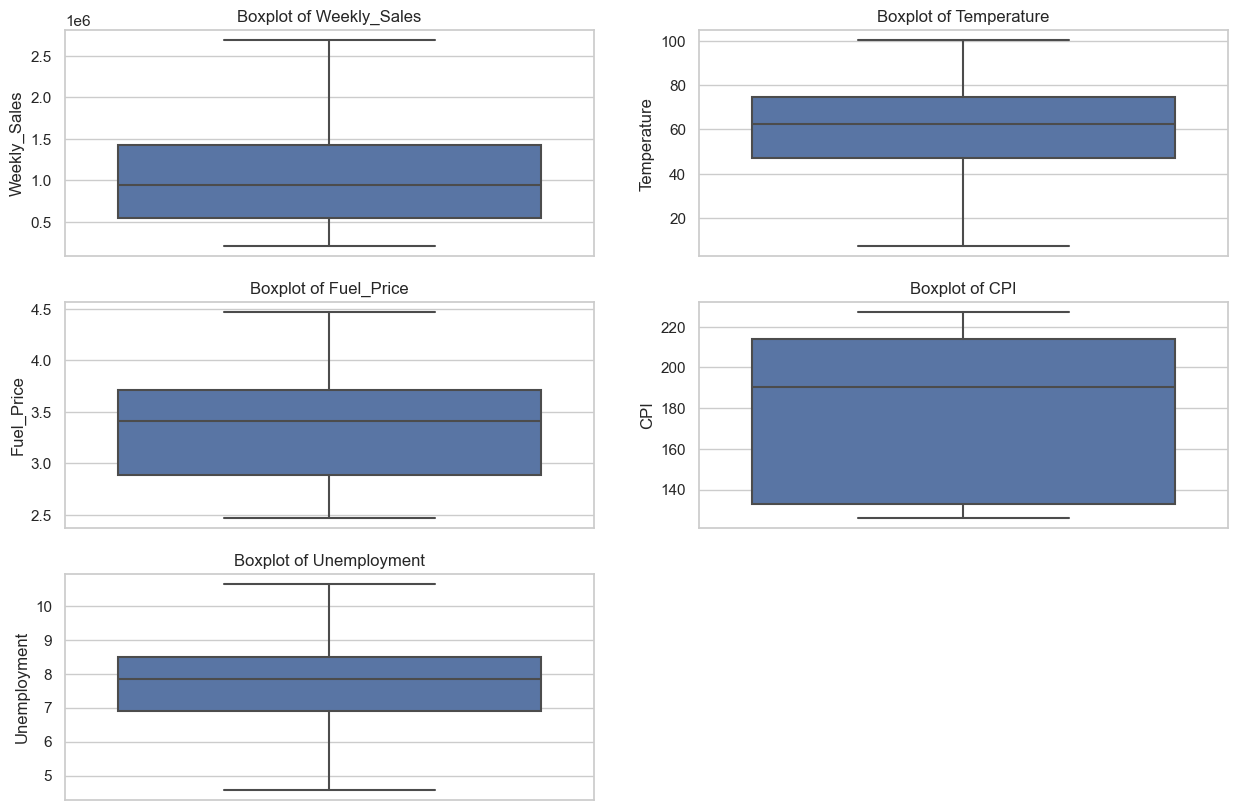

In [48]:
sns.set(style="whitegrid")

numerical_columns = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
\
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot of {col}')
plt.show()

In [16]:
def detect_outliers(df, feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]

for feature in numerical_columns:
    outliers = detect_outliers(df, feature)
    print(f"Outliers in {feature}:")
    print(outliers)

Outliers in Weekly_Sales:
      Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
189       2  24-12-2010    3436007.68             0        49.97       2.886   
241       2  23-12-2011    3224369.80             0        46.66       3.112   
471       4  26-11-2010    2789469.45             1        48.08       2.752   
474       4  17-12-2010    2740057.14             0        46.57       2.884   
475       4  24-12-2010    3526713.39             0        43.21       2.887   
523       4  25-11-2011    3004702.33             1        47.96       3.225   
526       4  16-12-2011    2771397.17             0        36.44       3.149   
527       4  23-12-2011    3676388.98             0        35.92       3.103   
761       6  24-12-2010    2727575.18             0        55.07       2.886   
1329     10  26-11-2010    2939946.38             1        55.33       3.162   
1332     10  17-12-2010    2811646.85             0        59.15       3.125   
1333     10  2

In [22]:
for feature in numerical_columns:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

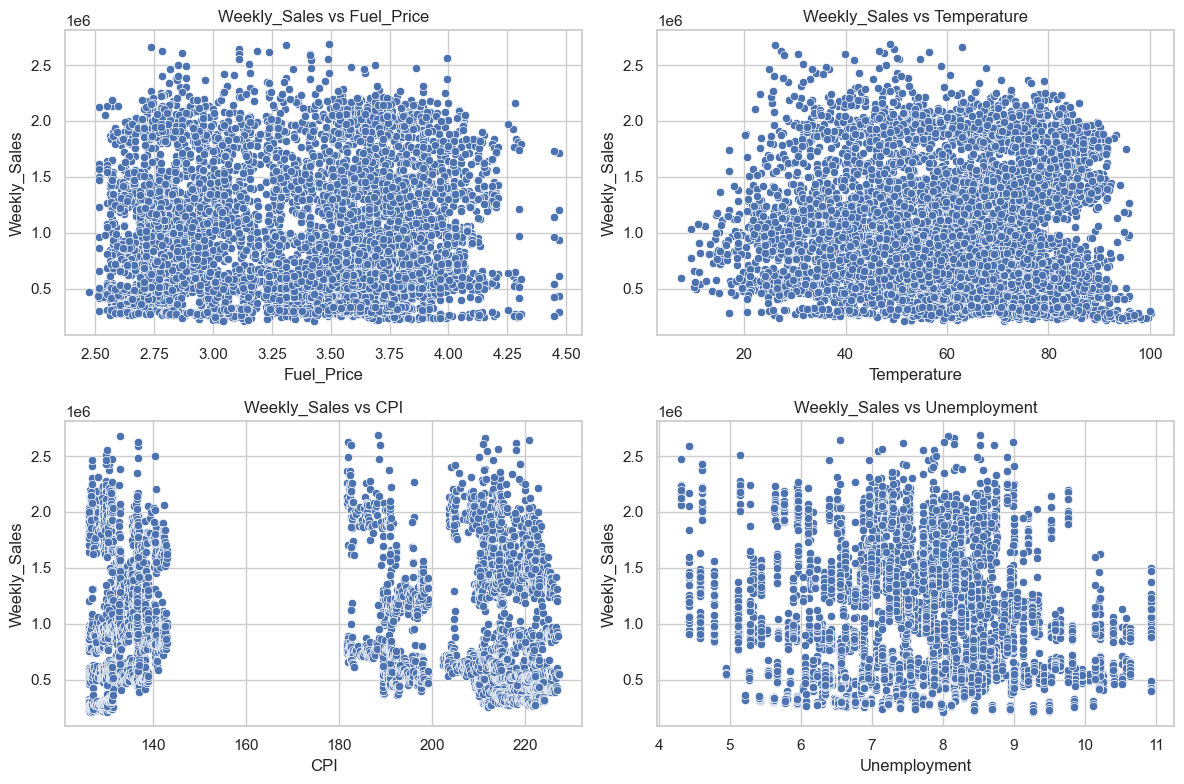

In [19]:
explanatory_features = ['Fuel_Price', 'Temperature', 'CPI', 'Unemployment']

plt.figure(figsize=(12, 8))
for i, feature in enumerate(explanatory_features, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(x=df[feature], y=df['Weekly_Sales'])
    plt.title(f'Weekly_Sales vs {feature}')
plt.tight_layout()
plt.show()

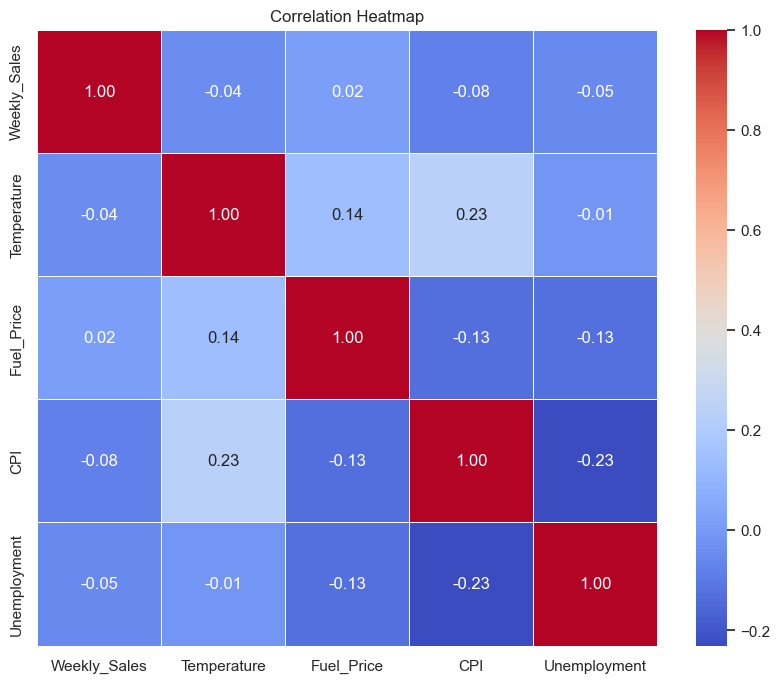

In [49]:
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## Part-2

In [60]:
X_temp = df['Temperature'].values.reshape(-1, 1)
y_sales = df['Weekly_Sales'].values

model_temp = LinearRegression()
model_temp.fit(X_temp, y_sales)

slope_temp = model_temp.coef_[0]
intercept_temp = model_temp.intercept_

y_pred_temp = model_temp.predict(X_temp)

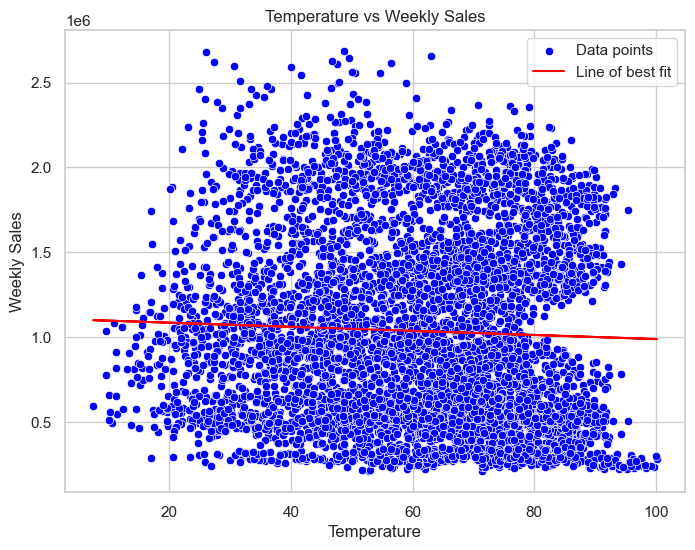

In [61]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Temperature'], y=df['Weekly_Sales'], color='blue', label='Data points')
plt.plot(df['Temperature'], y_pred_temp, color='red', label='Line of best fit')
plt.title('Temperature vs Weekly Sales')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

In [64]:
r2_temp = model_temp.score(X_temp, y_sales)
print(f"Temperature vs Weekly Sales: R^2 = {r2_temp}")
print(f"Slope: {slope_temp:.2f}, Intercept: {intercept_temp}")

Temperature vs Weekly Sales: R^2 = 0.0015963653445268955
Slope: -1204.42, Intercept: 1109065.1071510203


In [30]:
X_fuel = df['Fuel_Price'].values.reshape(-1, 1)

model_fuel = LinearRegression()
model_fuel.fit(X_fuel, y_sales)

slope_fuel = model_fuel.coef_[0]
intercept_fuel = model_fuel.intercept_

y_pred_fuel = model_fuel.predict(X_fuel)

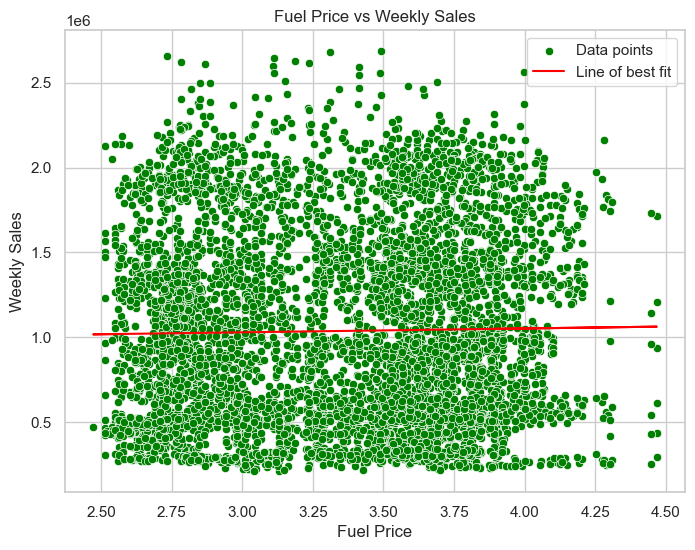

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Fuel_Price'], y=df['Weekly_Sales'], color='green', label='Data points')
plt.plot(df['Fuel_Price'], y_pred_fuel, color='red', label='Line of best fit')
plt.title('Fuel Price vs Weekly Sales')
plt.xlabel('Fuel Price')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

In [65]:
r2_fuel = model_fuel.score(X_fuel, y_sales)
print(f"Fuel Price vs Weekly Sales: R^2 = {r2_fuel}")
print(f"Slope: {slope_fuel:.2f}, Intercept: {intercept_fuel}")

Fuel Price vs Weekly Sales: R^2 = 0.0003562336898104146
Slope: 22703.63, Intercept: 960711.8255679873


In [33]:
X_unemp = df['Unemployment'].values.reshape(-1, 1)

model_unemp = LinearRegression()
model_unemp.fit(X_unemp, y_sales)

slope_unemp = model_unemp.coef_[0]
intercept_unemp = model_unemp.intercept_

y_pred_unemp = model_unemp.predict(X_unemp)

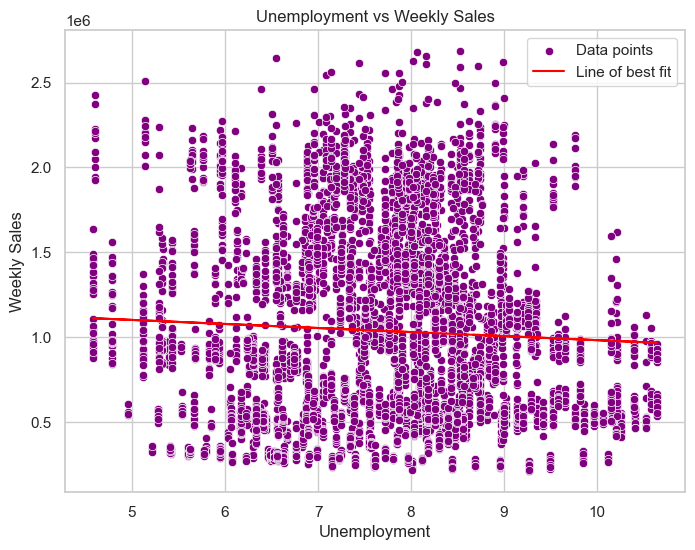

In [34]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Unemployment'], y=df['Weekly_Sales'], color='purple', label='Data points')
plt.plot(df['Unemployment'], y_pred_unemp, color='red', label='Line of best fit')
plt.title('Unemployment vs Weekly Sales')
plt.xlabel('Unemployment')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

In [66]:
r2_unemp = model_unemp.score(X_unemp, y_sales)
print(f"Unemployment vs Weekly Sales: R^2 = {r2_unemp}")
print(f"Slope: {slope_unemp:.2f}, Intercept: {intercept_unemp}")

Unemployment vs Weekly Sales: R^2 = 0.00267411153965047
Slope: -23880.75, Intercept: 1220868.4764486626


In [70]:
print("Comparison of R-squared values:")
print(f"Temperature vs Weekly Sales: R^2 = {r2_temp}")
print(f"Fuel Price vs Weekly Sales: R^2 = {r2_fuel}")
print(f"Unemployment vs Weekly Sales: R^2 = {r2_unemp}")

best_predictor = max(r2_temp, r2_fuel, r2_unemp)
if best_predictor == r2_temp:
    print("Temperature is the best predictor of Weekly Sales.")
elif best_predictor == r2_fuel:
    print("Fuel Price is the best predictor of Weekly Sales.")
else:
    print("Unemployment is the best predictor of Weekly Sales.")

Comparison of R-squared values:
Temperature vs Weekly Sales: R^2 = 0.0015963653445268955
Fuel Price vs Weekly Sales: R^2 = 0.0003562336898104146
Unemployment vs Weekly Sales: R^2 = 0.00267411153965047
Unemployment is the best predictor of Weekly Sales.


## Part-3

In [40]:
corr_temp, _ = pearsonr(df['Weekly_Sales'], df['Temperature'])

n = len(df)
t_stat_temp = corr_temp * np.sqrt(n - 2) / np.sqrt(1 - corr_temp**2)

from scipy.stats import t as t_dist
p_value_temp = 2 * (1 - t_dist.cdf(np.abs(t_stat_temp), df=n-2))

print(f"Temperature vs Weekly Sales: Correlation = {corr_temp:.2f}, T-statistic = {t_stat_temp:.2f}, p-value = {p_value_temp:.4f}")

Temperature vs Weekly Sales: Correlation = -0.04, T-statistic = -3.05, p-value = 0.0023


#### Since p-value is less than significance level, we would reject the null hypothesis which means that the correlation is statistically significant.

In [42]:
corr_fuel, _ = pearsonr(df['Weekly_Sales'], df['Fuel_Price'])

t_stat_fuel = corr_fuel * np.sqrt(n - 2) / np.sqrt(1 - corr_fuel**2)

p_value_fuel = 2 * (1 - t_dist.cdf(np.abs(t_stat_fuel), df=n-2))

print(f"Fuel Price vs Weekly Sales: Correlation = {corr_fuel:.2f}, T-statistic = {t_stat_fuel:.2f}, p-value = {p_value_fuel:.4f}")

Fuel Price vs Weekly Sales: Correlation = 0.02, T-statistic = 1.44, p-value = 0.1493


#### Since p-value is greater than significance level, we fail to reject the null hypothesis which means that the correlation is not statistically significant.

In [43]:
corr_unemp, _ = pearsonr(df['Weekly_Sales'], df['Unemployment'])

t_stat_unemp = corr_unemp * np.sqrt(n - 2) / np.sqrt(1 - corr_unemp**2)

p_value_unemp = 2 * (1 - t_dist.cdf(np.abs(t_stat_unemp), df=n-2))

print(f"Unemployment vs Weekly Sales: Correlation = {corr_unemp:.2f}, T-statistic = {t_stat_unemp:.2f}, p-value = {p_value_unemp:.4f}")

Unemployment vs Weekly Sales: Correlation = -0.05, T-statistic = -3.96, p-value = 0.0001


#### Since p-value is less than significance level, we would reject the null hypothesis which means that the correlation is statistically significant.

In [53]:
import statsmodels.formula.api as smf

# Use the formula API for OLS regression
model_temp = smf.ols('Weekly_Sales ~ Temperature', data=df).fit()

# Perform ANOVA
anova_temp = sm.stats.anova_lm(model_temp, typ=2)
print("ANOVA for Temperature vs Weekly Sales:")
print(anova_temp)

ANOVA for Temperature vs Weekly Sales:
                   sum_sq      df         F    PR(>F)
Temperature  2.829141e+12     1.0  9.332883  0.002261
Residual     1.769410e+15  5837.0       NaN       NaN


In [54]:
import statsmodels.formula.api as smf

model_temp = smf.ols('Weekly_Sales ~ Temperature', data=df).fit()

anova_temp = sm.stats.anova_lm(model_temp, typ=2)
print("ANOVA for Temperature vs Weekly Sales:")
print(anova_temp)

ANOVA for Temperature vs Weekly Sales:
                   sum_sq      df         F    PR(>F)
Temperature  2.829141e+12     1.0  9.332883  0.002261
Residual     1.769410e+15  5837.0       NaN       NaN


In [68]:
model_unemp = smf.ols('Weekly_Sales ~ Unemployment', data=df).fit()

anova_unemp = sm.stats.anova_lm(model_unemp, typ=2)
print("ANOVA for Unemployment vs Weekly Sales:")
print(anova_unemp)

ANOVA for Unemployment vs Weekly Sales:
                    sum_sq      df          F    PR(>F)
Unemployment  4.739166e+12     1.0  15.650641  0.000077
Residual      1.767500e+15  5837.0        NaN       NaN


In [74]:
model_temp = smf.ols('Weekly_Sales ~ Temperature', data=df).fit()

model_fuel = smf.ols('Weekly_Sales ~ Fuel_Price', data=df).fit()

model_unemp = smf.ols('Weekly_Sales ~ Unemployment', data=df).fit()

import statsmodels.api as sm

anova_temp = sm.stats.anova_lm(model_temp, typ=2)
print("\nANOVA for Temperature vs Weekly Sales:")
print(anova_temp)

anova_fuel = sm.stats.anova_lm(model_fuel, typ=2)
print("\nANOVA for Fuel Price vs Weekly Sales:")
print(anova_fuel)

anova_unemp = sm.stats.anova_lm(model_unemp, typ=2)
print("\nANOVA for Unemployment vs Weekly Sales:")
print(anova_unemp)


ANOVA for Temperature vs Weekly Sales:
                   sum_sq      df         F    PR(>F)
Temperature  2.829141e+12     1.0  9.332883  0.002261
Residual     1.769410e+15  5837.0       NaN       NaN

ANOVA for Fuel Price vs Weekly Sales:
                  sum_sq      df         F    PR(>F)
Fuel_Price  6.313313e+11     1.0  2.080077  0.149286
Residual    1.771608e+15  5837.0       NaN       NaN

ANOVA for Unemployment vs Weekly Sales:
                    sum_sq      df          F    PR(>F)
Unemployment  4.739166e+12     1.0  15.650641  0.000077
Residual      1.767500e+15  5837.0        NaN       NaN


In [75]:
# Extract coefficients, R² values, and p-values for Temperature model
coef_temp = model_temp.params['Temperature']
r2_temp = model_temp.rsquared
p_value_temp = model_temp.pvalues['Temperature']

# Extract coefficients, R² values, and p-values for Fuel Price model
coef_fuel = model_fuel.params['Fuel_Price']
r2_fuel = model_fuel.rsquared
p_value_fuel = model_fuel.pvalues['Fuel_Price']

# Extract coefficients, R² values, and p-values for Unemployment model
coef_unemp = model_unemp.params['Unemployment']
r2_unemp = model_unemp.rsquared
p_value_unemp = model_unemp.pvalues['Unemployment']

# Print the extracted metrics
print("\nMetrics for Temperature vs Weekly Sales:")
print(f"Coefficient: {coef_temp}")
print(f"R-squared: {r2_temp}")
print(f"P-value: {p_value_temp}")

print("\nMetrics for Fuel Price vs Weekly Sales:")
print(f"Coefficient: {coef_fuel}")
print(f"R-squared: {r2_fuel}")
print(f"P-value: {p_value_fuel}")

print("\nMetrics for Unemployment vs Weekly Sales:")
print(f"Coefficient: {coef_unemp}")
print(f"R-squared: {r2_unemp}")
print(f"P-value: {p_value_unemp}")


Metrics for Temperature vs Weekly Sales:
Coefficient: -1204.4165252358353
R-squared: 0.0015963653445268955
P-value: 0.0022609381989943385

Metrics for Fuel Price vs Weekly Sales:
Coefficient: 22703.632038743206
R-squared: 0.0003562336898104146
P-value: 0.1492862968602044

Metrics for Unemployment vs Weekly Sales:
Coefficient: -23880.7488383349
R-squared: 0.002674111539650581
P-value: 7.708979431199788e-05


### Since the absolute value of Unemployment vs Weekly Sales is the maximum amongst all, so Unemployment will have the highest impact on weekly sales.